# Go Game Review Analyser

Date: `2026-03-25`

Author: `@sthornewillve`

This notebook is the prototype that takes go games analysed and creates a database from them in order to analyse.

___

# Setup Notebook

In [1]:
import os
import json
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from openai import OpenAI
from pprint import pprint
from go_game_analyser_helperfuncs import analyse_game_review_summary, analyse_review_notes, analyse_playing_style, analyse_tags, save_analysis

In [2]:
# Create OpenAI Connection
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Import prompts
with open("prompt_configs.json") as f:
    prompts = json.load(f)

In [3]:
# Get game review summaries
conn = sqlite3.connect("game_reviews.db")
game_review_df = pd.read_sql("SELECT * FROM reviews", conn)
game_review_df.head()

,date,opponents_name,server,game_link,result,played_as,is_won_game,handicap,time_setting,review_notes,key_mistake,key_mistake_cause,positive_point,game_tags
0,2026-03-31,krpic,OGS,https://ai-sensei.com/game/VGIPT5au1Jg6jxQRo6P...,W+R,Black,0,0,10m + 10s/mv,\n* End of game notes\n\t* I tried a deep inva...,Failed deep invasion,Tried to kill when the shape wasn't right,Played a new joseki,Tried too hard to kill; Misplayed invasion; Mi...
1,2026-03-27,yuki22,OGS,https://ai-sensei.com/game/VGIPT5au1Jg6jxQRo6P...,B+R,White,0,0,20 + 5x30s,\n* End of game notes\n\t* Black managed to ki...,Wedge misplay,misread wedge,Made a large area,Created moyo; Ko situation; Tried too hard to ...
2,2026-03-27,qp1029,OGS,https://ai-sensei.com/game/VGIPT5au1Jg6jxQRo6P...,B+R,White,0,1,20m + 5x30s,\n* End of game notes\n\t* White resigns too e...,Resigning too early,miscounted score / didn't realize lead,Large kill and top-side territory,Resigned too early; Didn't count score; Exploi...
3,2026-03-24,dienfoonwu,OGS,https://ai-sensei.com/game/VGIPT5au1Jg6jxQRo6P...,B+R,White,0,3,20m + 5x30s,\n* End of game notes\n\t* Got surrounded and ...,Allowing atari,Allowed atari that weakened the group,Exploited opponent's weak shape to create two ...,Exploited opponent's weak shape; Died with sur...
4,2026-03-26,xiaoqiang2026,OGS,https://ai-sensei.com/game/VGIPT5au1Jg6jxQRo6P...,B+9.5,White,0,1,20m + 5x30s,\n* End of game notes\n\t* Both players manage...,Missed kill,misread killing point at F2,Created moyo,Missed kill; Created moyo; Endgame trouble; Ko...


___

# Analyse Games

In [4]:
summary = analyse_game_review_summary(game_review_df, client, prompts)

pprint(summary)

{'did_well': 'You consistently build large territorial frameworks (moyo) and '
             'pressure weak shapes, often turning games with purposeful '
             'attacks and solid center play.',
 'needs_work': 'Improve life-and-death reading and endgame accuracy (killing '
               'points, tesuji timing, and score counting); reduce '
               'over-ambitious invasions and premature resignations, and stay '
               'active with precise, pressure-building moves.'}


In [5]:
notes_analysis = analyse_review_notes(game_review_df, client, prompts)

In [6]:
pprint(notes_analysis["overall_impression"])

('The player shows a strong fighting instinct, willingness to experiment with '
 'openings and mid-game plans, and capacity to create large territories. '
 'However, life-and-death reading and threat assessment are recurring '
 'bottlenecks, leading to overambitious invasions, misread ko situations, and '
 'endgame point losses. The single most impactful area to improve is threat '
 'evaluation and life calculation in fights, which should help curtail '
 'overextensions and translate aggressive plays into more consistent, durable '
 'advantages.')


In [7]:
pprint(notes_analysis["recurring_mistakes"])

[{'cause_hypothesis': 'Overcommitting to aggressive threats without solid '
                      'follow-up or life assurance, driven by a tendency to '
                      'pressure flaws rather than verify living shapes.',
  'focus': 'Only threaten or attack when you have a concrete, forcing '
           'continuation or a guaranteed lifeline; add a quick life check '
           'around attacked areas before pushing.',
  'pattern': 'Threat_overextension'},
 {'cause_hypothesis': 'Invasions deep into opponent territory are attempted '
                      'without reliable local life or escape paths, leading to '
                      'costly losses or unsound positions.',
  'focus': 'Assess local life and liberties first; practice quick '
           'life-and-death judgments on common deep-invasion shapes before '
           'committing.',
  'pattern': 'Deep_invasion_life_misjudgment'},
 {'cause_hypothesis': 'Misreading ko threats and liberties causes '
                      'misc

In [8]:
pprint(notes_analysis["recurring_strengths"])

[{'cause_hypothesis': 'Stronger ability to recognize when a ko threat is not '
                      'truly threatening, avoiding wasted moves and '
                      'overcommitment.',
  'pattern': 'Ko_threat_recognition'},
 {'cause_hypothesis': 'Solid sense of endgame timing, creating and leveraging '
                      'sente opportunities to extract points.',
  'pattern': 'Endgame_sente_execution'},
 {'cause_hypothesis': 'Good eye for identifying weak groups and converting '
                      'those targets into tangible gains.',
  'pattern': 'Attack_weak_groups_profitably'},
 {'cause_hypothesis': 'Willingness to stay active and fight when behind, often '
                      'turning battles into salvageable or winning outcomes.',
  'pattern': 'Resilience_in_fights'},
 {'cause_hypothesis': 'Openness to try new joseki and shapes, gaining '
                      'experience and adaptability across games.',
  'pattern': 'Joseki_experimentation'},
 {'cause_hypothesis': 'Co

In [9]:
# playing_style = analyse_playing_style(
#     game_review_df,
#     client,
#     prompts,
#     context={"summary": summary, "notes_analysis": notes_analysis},
#     n_runs=10,
# )

In [10]:
# playing_style["scores"] = playing_style["scores"]\
#     .assign(reasoning = [i["reasoning"] for i in playing_style["dimensions"].values()])\
#     .assign(style = lambda df: df["dimension"].map({
#         "Knowledge": "calm",
#         "Territorial Intuition": "calm",
#         "Strategy": "calm",
#         "Mind Control": "calm",
#         "Reading": "aggressive",
#         "Technical Intuition": "aggressive",
#         "Game Experience": "aggressive"
#     }))

# playing_style["scores"]



In [11]:
# # Modify scores for aggressive styles
# playing_style["scores"] = playing_style["scores"].assign(
#     style_score=lambda df: df.apply(lambda row: -row["score"] if row["style"] == "aggressive" else row["score"], axis=1)
# )

# # Compute weighted average
# avg_calm = playing_style["scores"][playing_style["scores"]["style"] == "calm"]["style_score"].mean()
# avg_agg = playing_style["scores"][playing_style["scores"]["style"] == "aggressive"]["style_score"].mean()
# unweighted_avg = playing_style["scores"]["style_score"].mean()
# weighted_avg = (3/7) * avg_calm + (4/7) * avg_agg

# print(f"Unweighted average score: {unweighted_avg}")
# print(f"Weighted average score: {weighted_avg}")

In [12]:
# pprint(playing_style["scores"]\
#     .sort_values("score", ascending=True)\
#     .query("score <= 5")["reasoning"].values)

In [13]:
# pprint(playing_style["scores"]\
#     .sort_values("score", ascending=True)\
#     .query("score > 5")["reasoning"].values)

In [14]:
df_tag_counts_by_result = (
    game_review_df
    .assign(game_tags=game_review_df["game_tags"].str.split(";"))
    .explode("game_tags")
    .assign(game_tags=lambda df: df["game_tags"].str.strip())
    .groupby(["game_tags", "is_won_game"])
    .size()
    .reset_index(name="count")
    .rename(columns={"game_tags": "tag"})
    .assign(result=lambda df: df["is_won_game"].map({1: "Won", 0: "Lost"}))
    .drop(columns="is_won_game")
    .sort_values("count", ascending=False)
)

df_tag_counts_by_result.head(10)

,tag,count,result
6,Endgame trouble,7,Lost
9,Exploited opponent's weak shape,5,Won
1,Created moyo,5,Lost
13,Ko situation,4,Lost
2,Created moyo,3,Won
41,Tried too hard to kill,3,Lost
34,Played solid game,3,Won
22,Missed kill,2,Lost
29,Outplayed opponent,2,Won
8,Exploited opponent's weak shape,2,Lost


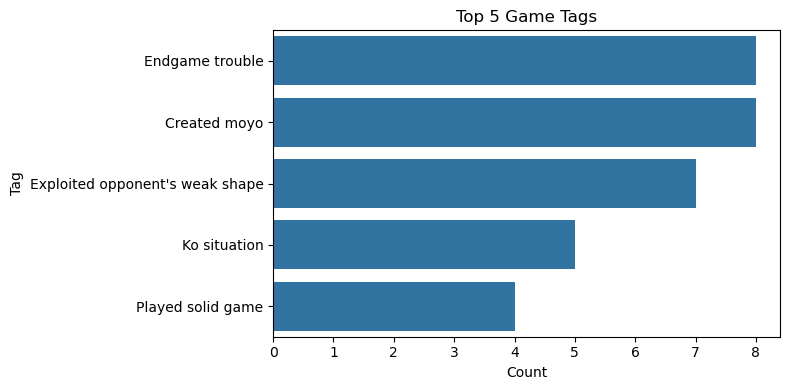

In [15]:
# Visualise Tags
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_tag_counts_by_result.groupby(["tag"], as_index=False)["count"].sum()\
            .sort_values(by='count', ascending=False).head(5), x='count', y='tag', ax=ax)
ax.set(title="Top 5 Game Tags", xlabel="Count", ylabel="Tag")
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
plt.tight_layout()
plt.show()


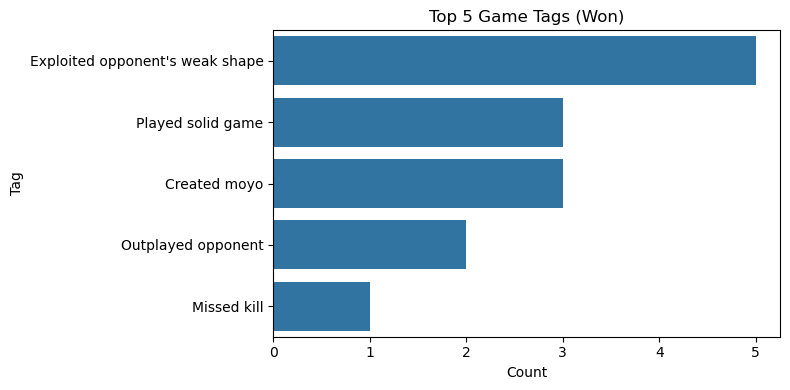

In [16]:
# Visualise Won Tags
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_tag_counts_by_result[df_tag_counts_by_result["result"] == "Won"]\
            .sort_values(by='count', ascending=False).head(5), x='count', y='tag', ax=ax)
ax.set(title="Top 5 Game Tags (Won)", xlabel="Count", ylabel="Tag")
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
plt.tight_layout()
plt.show()


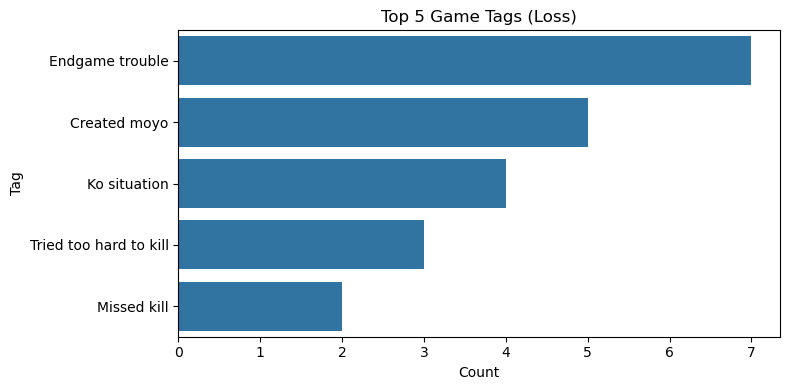

In [17]:
# Visualise Won Tags
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_tag_counts_by_result[df_tag_counts_by_result["result"] == "Lost"]\
            .sort_values(by='count', ascending=False).head(5), x='count', y='tag', ax=ax)
ax.set(title="Top 5 Game Tags (Loss)", xlabel="Count", ylabel="Tag")
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
plt.tight_layout()
plt.show()


___

# Save Analysis

In [18]:
save_analysis(game_review_df, summary, notes_analysis)

Saved analysis for period 2026-03-21 → 2026-04-02
